In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from policies import RLLRPolicy

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

weights_path = "./gru_priors.pth"

trained_policy = RLLRPolicy(state_dim=2, hidden_dim=64, num_groups=6, action_bounds=(0.5, 2.0), weights_path=weights_path).to(device)

xavier_policy = RLLRPolicy(
    state_dim=2,
    hidden_dim=64,
    num_groups=6,
    action_bounds=(0.5, 2.0),
    weights_path=None,
).to(device)

Using device: cpu


In [21]:
def analyze_weight_differences(trained_model, xavier_model, layer_name_filter=None):
    """Analyze differences between trained and Xavier-initialized weights"""

    results = {}

    for (name1, param1), (name2, param2) in zip(trained_model.named_parameters(), xavier_model.named_parameters()):
        assert name1 == name2, f"Parameter names don't match: {name1} vs {name2}"

        if layer_name_filter and layer_name_filter not in name1:
            continue

        # Calculate differences
        diff = param1.data - param2.data

        # Statistics
        mean_diff = diff.mean().item()
        std_diff = diff.std().item()
        max_diff = diff.abs().max().item()

        # Relative differences (avoid division by zero)
        xavier_norm = param2.data.norm().item()
        trained_norm = param1.data.norm().item()
        relative_norm_diff = abs(trained_norm - xavier_norm) / (xavier_norm + 1e-8)

        # Cosine similarity
        flat_trained = param1.data.flatten()
        flat_xavier = param2.data.flatten()
        cosine_sim = torch.nn.functional.cosine_similarity(flat_trained.unsqueeze(0), flat_xavier.unsqueeze(0)).item()

        results[name1] = {
            "shape": list(param1.shape),
            "mean_diff": mean_diff,
            "std_diff": std_diff,
            "max_abs_diff": max_diff,
            "trained_norm": trained_norm,
            "xavier_norm": xavier_norm,
            "relative_norm_diff": relative_norm_diff,
            "cosine_similarity": cosine_sim,
            "trained_data": param1.data.cpu().numpy(),
            "xavier_data": param2.data.cpu().numpy(),
            "diff_data": diff.cpu().numpy(),
        }

    return results


analysis = analyze_weight_differences(trained_policy, xavier_policy)

# Print summary statistics
for param_name, stats in analysis.items():
    print(f"\n{param_name} {stats['shape']}\n")

    print(f"Mean difference: {stats['mean_diff']:.6f}")
    print(f"Std of differences: {stats['std_diff']:.6f}")
    print(f"Max absolute difference: {stats['max_abs_diff']:.6f}")
    print(f"Trained norm: {stats['trained_norm']:.6f}")
    print(f"Xavier norm: {stats['xavier_norm']:.6f}")
    print(f"Relative norm difference: {stats['relative_norm_diff']:.4f}")
    print(f"Cosine similarity: {stats['cosine_similarity']:.6f}")

    print()


gru.weight_ih_l0 [192, 2]

Mean difference: 0.005436
Std of differences: 0.031425
Max absolute difference: 0.067782
Trained norm: 0.583538
Xavier norm: 0.206871
Relative norm difference: 1.8208
Cosine similarity: -0.025889


gru.weight_hh_l0 [192, 64]

Mean difference: 0.001087
Std of differences: 0.031913
Max absolute difference: 0.067563
Trained norm: 3.405792
Xavier norm: 0.972647
Relative norm difference: 2.5016
Cosine similarity: 0.002592


gru.bias_ih_l0 [192]

Mean difference: 0.005803
Std of differences: 0.031333
Max absolute difference: 0.037539
Trained norm: 0.440437
Xavier norm: 0.000000
Relative norm difference: 44043678.0453
Cosine similarity: 0.000000


gru.bias_hh_l0 [192]

Mean difference: 0.005844
Std of differences: 0.031519
Max absolute difference: 0.037539
Trained norm: 0.443060
Xavier norm: 0.000000
Relative norm difference: 44306045.7706
Cosine similarity: 0.000000


mean_head.weight [6, 64]

Mean difference: 0.001073
Std of differences: 0.022848
Max absolute dif

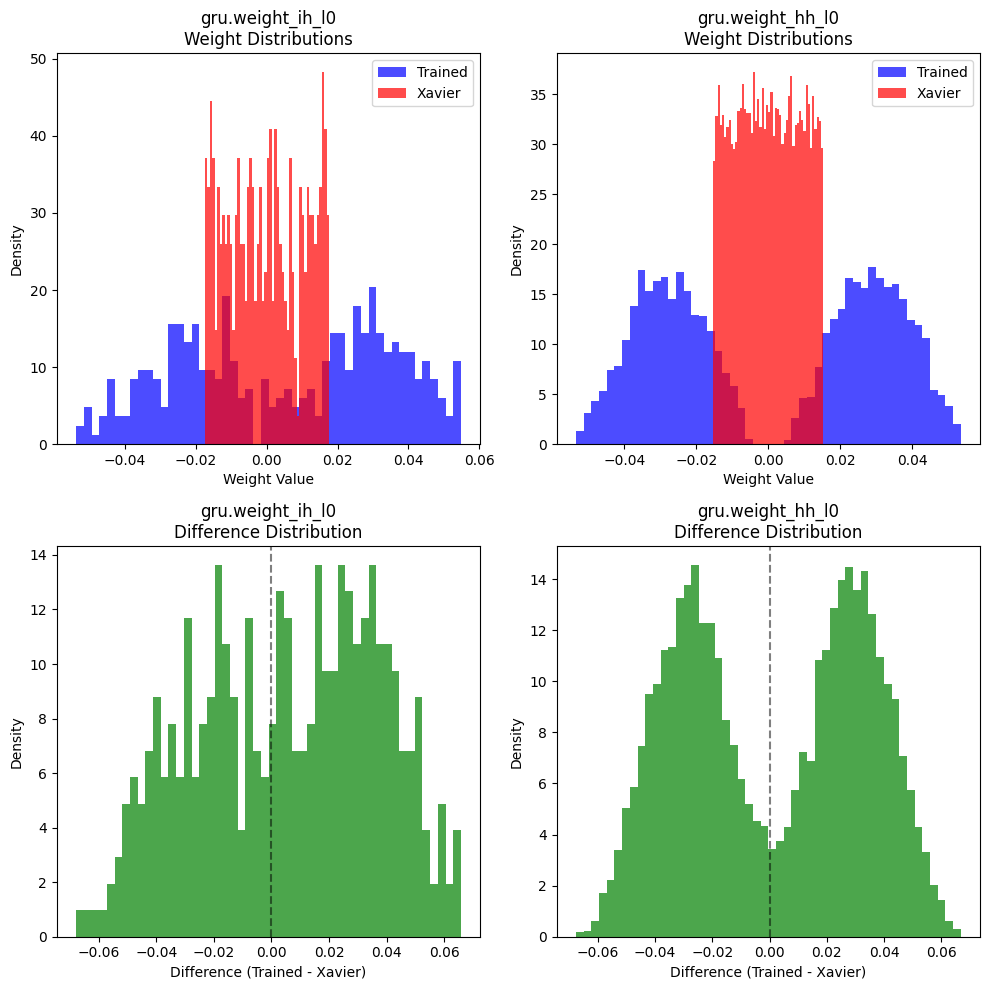

In [32]:
gru_params = {k: v for k, v in analysis.items() if "gru" in k and "weight" in k}

if gru_params:
    fig, axes = plt.subplots(2, len(gru_params), figsize=(5 * len(gru_params), 10))
    if len(gru_params) == 1:
        axes = axes.reshape(-1, 1)

    for idx, (param_name, stats) in enumerate(gru_params.items()):
        axes[0, idx].hist(stats["trained_data"].flatten(), bins=50, alpha=0.7, label="Trained", density=True, color="blue")
        axes[0, idx].hist(stats["xavier_data"].flatten(), bins=50, alpha=0.7, label="Xavier", density=True, color="red")
        axes[0, idx].set_title(f"{param_name}\nWeight Distributions")
        axes[0, idx].legend()
        axes[0, idx].set_xlabel("Weight Value")
        axes[0, idx].set_ylabel("Density")

        axes[1, idx].hist(stats["diff_data"].flatten(), bins=50, alpha=0.7, color="green", density=True)
        axes[1, idx].set_title(f"{param_name}\nDifference Distribution")
        axes[1, idx].set_xlabel("Difference (Trained - Xavier)")
        axes[1, idx].set_ylabel("Density")
        axes[1, idx].axvline(x=0, color="black", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

In [28]:
all_cosine_sims = [stats["cosine_similarity"] for stats in analysis.values()]
all_rel_norm_diffs = [stats["relative_norm_diff"] for stats in analysis.values()]

print(f"Average cosine similarity: {np.mean(all_cosine_sims):.4f}")
print(f"Min cosine similarity: {np.min(all_cosine_sims):.4f}")
print(f"Max cosine similarity: {np.max(all_cosine_sims):.4f}")
print(f"Average relative norm difference: {np.mean(all_rel_norm_diffs):.4f}")
print(f"Max relative norm difference: {np.max(all_rel_norm_diffs):.4f}")

Average cosine similarity: 0.0048
Min cosine similarity: -0.0259
Max cosine similarity: 0.0780
Average relative norm difference: 12057184.6993
Max relative norm difference: 44306045.7706
